# Tech Challenge - EDA

## Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## File

In [6]:
data = pd.read_csv('./desafio_nps_fase_1.csv')

## Dataset

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

###  Dataset Head

In [9]:
data.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### Dataset Basic Statistics

In [30]:
data.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


### Dataset Unique Values

In [31]:
total_unique = data['customer_id'].value_counts().sum()
print(f"Total number of unique customers with consolidated data: {total_unique}")


Total number of unique customers with consolidated data: 2500


## NPS

- ***Promotores*** (9-10): Clientes fiéis e satisfeitos.

- ***Neutros*** (7-8): Clientes passivos, não fiéis.

- ***Detratores*** (0-6): Clientes insatisfeitos, propensos a propaganda negativa.


---
#### **Cálculo NPS**
- **NPS = %Promotores - %Detratores**

### Promoters

In [32]:
promoters = data[data['nps_score'] > 8]
promoter_count = len(promoters)
print(f"Number of Promoters (NPS score > 8): {promoter_count}")

Number of Promoters (NPS score > 8): 201


### Neutral

In [33]:
neutral = data[(data['nps_score'] > 6) & (data['nps_score'] <= 8)]
neutral_count = len(neutral)
print(f"Number of Neutral (6 > NPS score <= 8): {neutral_count}")

Number of Neutral (6 > NPS score <= 8): 448


### Detractors

In [34]:
detractors = data[data['nps_score'] <= 6 ]
detractor_count = len(detractors)
print(f"Number of Detractors (NPS score <= 6): {detractor_count}")

Number of Detractors (NPS score <= 6): 1851


### NPS - Stats and Correlations



In [35]:
total_nps = promoter_count + neutral_count + detractor_count
promoters_percentage = (promoter_count / total_nps) * 100
neutral_percentage = (neutral_count / total_nps) * 100
detractors_percentage = (detractor_count / total_nps) * 100
nps_score = (promoters_percentage - detractors_percentage) * 100
print(f"Total NPS: {total_nps}")
print(f"Percentual Promoters: {promoters_percentage}")
print(f"Percentual Neutral: {neutral_percentage}")
print(f"Percentual Detractors: {detractors_percentage}")
print(f"NPS Score: {nps_score}")


Total NPS: 2500
Percentual Promoters: 8.04
Percentual Neutral: 17.919999999999998
Percentual Detractors: 74.03999999999999
NPS Score: -6600.0


#### Promoters NPS Correlation

In [37]:
promoters_numeric = promoters.drop(columns=['customer_id']).copy()
promoters_numeric = pd.get_dummies(promoters_numeric)

promoters_nps_correlation = promoters_numeric.corr()['nps_score'].sort_values(ascending=False)

print("Correlation of NPS Score with other features for Promoters:")
display(promoters_nps_correlation)

Correlation of NPS Score with other features for Promoters:


nps_score                       1.000000
csat_internal_score             0.233838
customer_region_Centro-Oeste    0.129293
delivery_attempts               0.085069
items_quantity                  0.079103
discount_value                  0.054777
customer_region_Nordeste        0.032027
payment_installments            0.024938
customer_tenure_months         -0.003329
order_value                    -0.008688
delivery_time_days             -0.019842
order_id                       -0.025252
freight_value                  -0.032257
customer_region_Norte          -0.043206
customer_region_Sudeste        -0.051985
customer_region_Sul            -0.054008
customer_age                   -0.076206
resolution_time_days           -0.102604
delivery_delay_days            -0.122648
complaints_count               -0.152587
customer_service_contacts      -0.156318
repeat_purchase_30d                  NaN
Name: nps_score, dtype: float64

##### Promoters Crossing Region Info

Crosstab from nps and customer region:




nps_score,8.1,8.2,8.3,8.4,8.5,8.6,8.7,8.8,8.9,9.0,9.1,9.2,9.3,9.4,9.5,9.6,9.7,9.8,9.9,10.0
customer_region,,,,,,,,,,,,,,,,,,,,
Centro-Oeste,1,0,0,2,2,1,1,2,2,1,4,3,2,0,3,0,2,1,0,9
Nordeste,2,1,1,1,2,1,3,2,0,1,2,3,1,2,3,2,0,1,0,6
Norte,2,2,4,3,0,2,3,3,1,1,1,1,0,3,0,4,0,0,1,7
Sudeste,3,4,2,3,1,1,3,2,1,2,6,0,2,1,0,2,0,0,1,9
Sul,7,2,2,3,3,2,1,4,3,0,2,1,1,4,0,0,1,2,1,11




---------------------------------------------------------------------------------------
Relation from nps and customer region:




<Axes: title={'center': 'nps_score'}, xlabel='customer_region'>

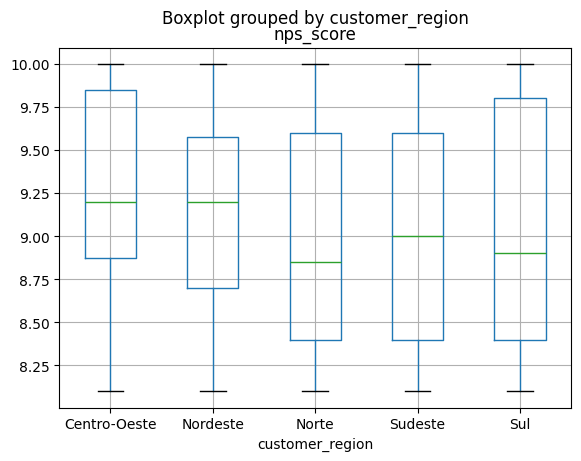

In [17]:
print("Crosstab from nps and customer region:")
print("\n")
cross = pd.crosstab(promoters['customer_region'], promoters['nps_score'])
display(cross)

print("\n")
print("---------------------------------------------------------------------------------------")
print("Relation from nps and customer region:")
print("\n")
promoters.boxplot(column='nps_score', by='customer_region')

#### Neutral NPS Correlation

In [18]:
neutral_numeric = neutral.drop(columns=['customer_id']).copy()
neutral_numeric = pd.get_dummies(neutral_numeric)

neutral_nps_correlation = neutral_numeric.corr()['nps_score'].sort_values(ascending=False)

print("Correlation of NPS Score with other features for Neutral:")
display(neutral_nps_correlation)

Correlation of NPS Score with other features for Neutral:


nps_score                       1.000000
repeat_purchase_30d             0.388736
csat_internal_score             0.155942
order_value                     0.059719
payment_installments            0.050913
customer_region_Centro-Oeste    0.039716
discount_value                  0.038449
customer_region_Sudeste         0.029263
freight_value                   0.019189
order_id                        0.006031
delivery_attempts               0.001560
delivery_time_days             -0.000173
customer_region_Sul            -0.003177
items_quantity                 -0.005658
customer_tenure_months         -0.024007
resolution_time_days           -0.027518
customer_region_Nordeste       -0.029575
customer_region_Norte          -0.034665
customer_age                   -0.043878
customer_service_contacts      -0.078173
complaints_count               -0.130843
delivery_delay_days            -0.228433
Name: nps_score, dtype: float64

##### Neutral Crossing Region Info

Crosstab from nps and customer region:




nps_score,6.1,6.2,6.3,6.4,6.5,6.6,6.7,6.8,6.9,7.0,7.1,7.2,7.3,7.4,7.5,7.6,7.7,7.8,7.9,8.0
customer_region,,,,,,,,,,,,,,,,,,,,
Centro-Oeste,6,6,7,4,5,2,6,6,4,3,1,3,7,2,6,2,6,3,2,3
Nordeste,7,7,6,5,0,15,6,5,5,8,1,6,3,4,0,2,1,3,5,3
Norte,6,4,7,6,9,5,4,7,6,8,6,5,4,1,0,2,3,3,3,2
Sudeste,9,8,2,5,4,4,7,5,3,3,8,3,2,5,3,6,3,2,4,3
Sul,8,3,8,10,8,2,2,11,3,6,2,2,4,1,4,4,4,0,4,6




---------------------------------------------------------------------------------------
Relation from nps and customer region:




<Axes: title={'center': 'nps_score'}, xlabel='customer_region'>

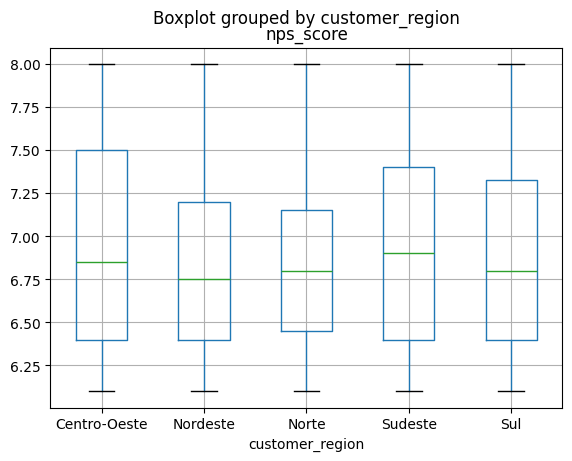

In [19]:
print("Crosstab from nps and customer region:")
print("\n")
cross = pd.crosstab(neutral['customer_region'], neutral['nps_score'])
display(cross)

print("\n")
print("---------------------------------------------------------------------------------------")
print("Relation from nps and customer region:")
print("\n")
neutral.boxplot(column='nps_score', by='customer_region')

#### Detractors NPS Correlation

In [38]:
detractors_numeric = detractors.drop(columns=['customer_id']).copy()
detractors_numeric = pd.get_dummies(detractors_numeric)

detractors_nps_correlation = detractors_numeric.corr()['nps_score'].sort_values(ascending=True)
print("\n")
print("Correlation of NPS Score with other features for Detractors:")
display(detractors_nps_correlation)



Correlation of NPS Score with other features for Detractors:


delivery_delay_days            -0.510163
complaints_count               -0.284063
customer_service_contacts      -0.280322
resolution_time_days           -0.124052
customer_region_Centro-Oeste   -0.062316
freight_value                  -0.035780
customer_age                   -0.030480
delivery_time_days             -0.012442
order_id                       -0.010970
customer_tenure_months         -0.008186
customer_region_Sudeste         0.004177
delivery_attempts               0.012704
customer_region_Sul             0.014662
customer_region_Norte           0.016734
order_value                     0.020048
payment_installments            0.020777
customer_region_Nordeste        0.025271
discount_value                  0.026001
items_quantity                  0.044885
csat_internal_score             0.437555
nps_score                       1.000000
repeat_purchase_30d                  NaN
Name: nps_score, dtype: float64

##### Detractors Crossing Region Info

Crosstab from nps and customer region:




nps_score,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,6.0
customer_region,,,,,,,,,,,,,,,,,,,,,
Centro-Oeste,34,2,4,5,5,3,1,3,3,3,...,5,6,9,4,7,6,2,3,5,2
Nordeste,31,2,0,2,2,1,2,1,3,4,...,4,9,11,7,5,9,3,7,9,8
Norte,34,0,1,0,6,2,3,6,5,2,...,7,9,8,9,10,8,6,14,5,6
Sudeste,27,3,4,2,1,0,2,3,4,7,...,7,7,10,5,10,8,8,9,4,8
Sul,32,1,5,1,0,3,1,2,2,2,...,4,7,3,5,8,9,8,6,5,10




---------------------------------------------------------------------------------------
Relation from nps and customer region:




<Axes: title={'center': 'nps_score'}, xlabel='customer_region'>

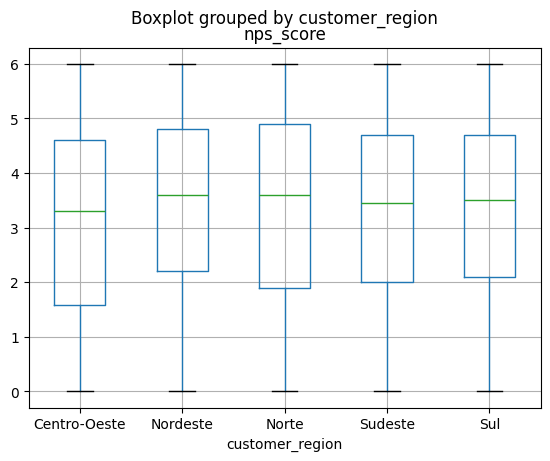

In [27]:
print("Crosstab from nps and customer region:")
print("\n")
cross = pd.crosstab(detractors['customer_region'], detractors['nps_score'])
display(cross)

print("\n")
print("---------------------------------------------------------------------------------------")
print("Relation from nps and customer region:")
print("\n")
detractors.boxplot(column='nps_score', by='customer_region')

### Detractors (alternative - without nps 0)

In [94]:
detractors_alternative = data[(data['nps_score'] <= 6) & ( data['nps_score'] > 0)]
detractor_count = len(detractors_alternative)
print(f"Number of Detractors (NPS 0 > score <= 6): {detractor_count}")

Number of Detractors (NPS 0 > score <= 6): 1693


#### Detractors (alternative) NPS Correlation

In [95]:
detractors_numeric = detractors_alternative.drop(columns=['customer_id']).copy()
detractors_numeric = pd.get_dummies(detractors_numeric)

detractors_nps_correlation = detractors_numeric.corr()['nps_score'].sort_values(ascending=True)
print("\n")
print("Correlation of NPS Score with other features for Detractors:")
display(detractors_nps_correlation)



Correlation of NPS Score with other features for Detractors:


,nps_score
delivery_delay_days,-0.435820
complaints_count,-0.215926
customer_service_contacts,-0.199088
resolution_time_days,-0.121250
customer_region_Centro-Oeste,-0.063909
order_id,-0.033827
freight_value,-0.032558
customer_age,-0.018939
customer_region_Sudeste,-0.015080
customer_tenure_months,-0.009423


##### Detractors (alternative) Crossing Region Info

Crosstab from nps and customer region:




nps_score,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,...,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,6.0
customer_region,,,,,,,,,,,,,,,,,,,,,
Centro-Oeste,2,4,5,5,3,1,3,3,3,3,...,5,6,9,4,7,6,2,3,5,2
Nordeste,2,0,2,2,1,2,1,3,4,2,...,4,9,11,7,5,9,3,7,9,8
Norte,0,1,0,6,2,3,6,5,2,2,...,7,9,8,9,10,8,6,14,5,6
Sudeste,3,4,2,1,0,2,3,4,7,2,...,7,7,10,5,10,8,8,9,4,8
Sul,1,5,1,0,3,1,2,2,2,1,...,4,7,3,5,8,9,8,6,5,10




---------------------------------------------------------------------------------------
Relation from nps and customer region:




<Axes: title={'center': 'nps_score'}, xlabel='customer_region'>

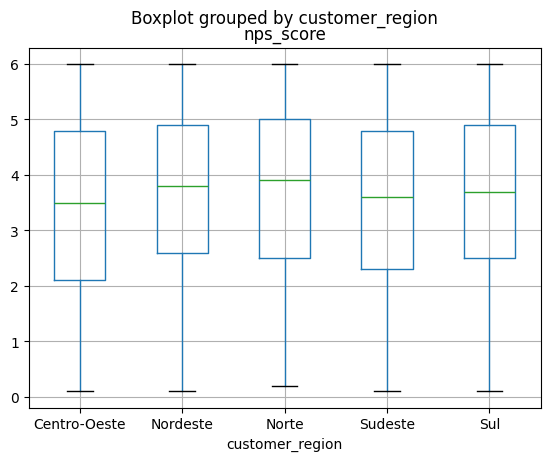

In [96]:
print("Crosstab from nps and customer region:")
print("\n")
cross = pd.crosstab(detractors_alternative['customer_region'], detractors_alternative['nps_score'])
display(cross)

print("\n")
print("---------------------------------------------------------------------------------------")
print("Relation from nps and customer region:")
print("\n")
detractors_alternative.boxplot(column='nps_score', by='customer_region')

## HeatMap

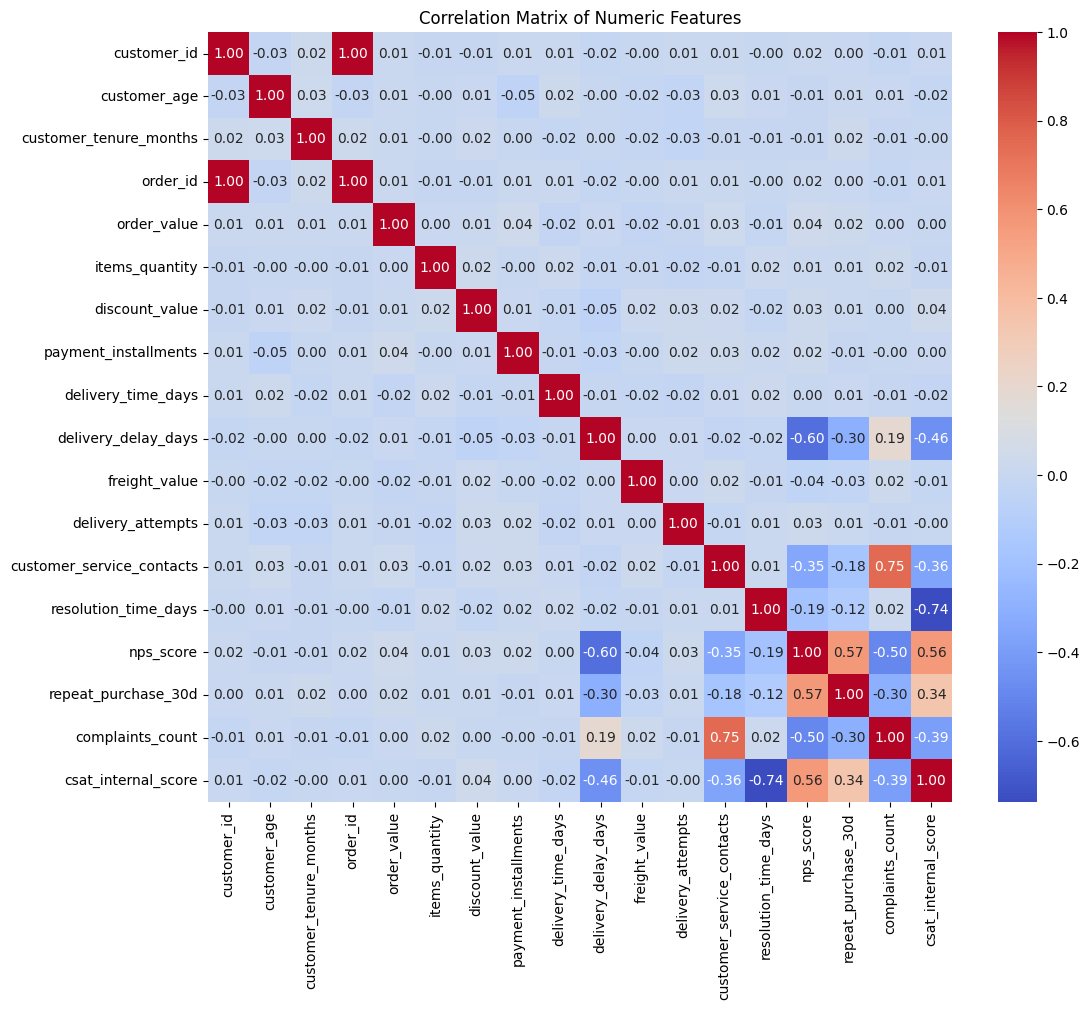

In [101]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.drop(columns=['customer_region']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Pairplot

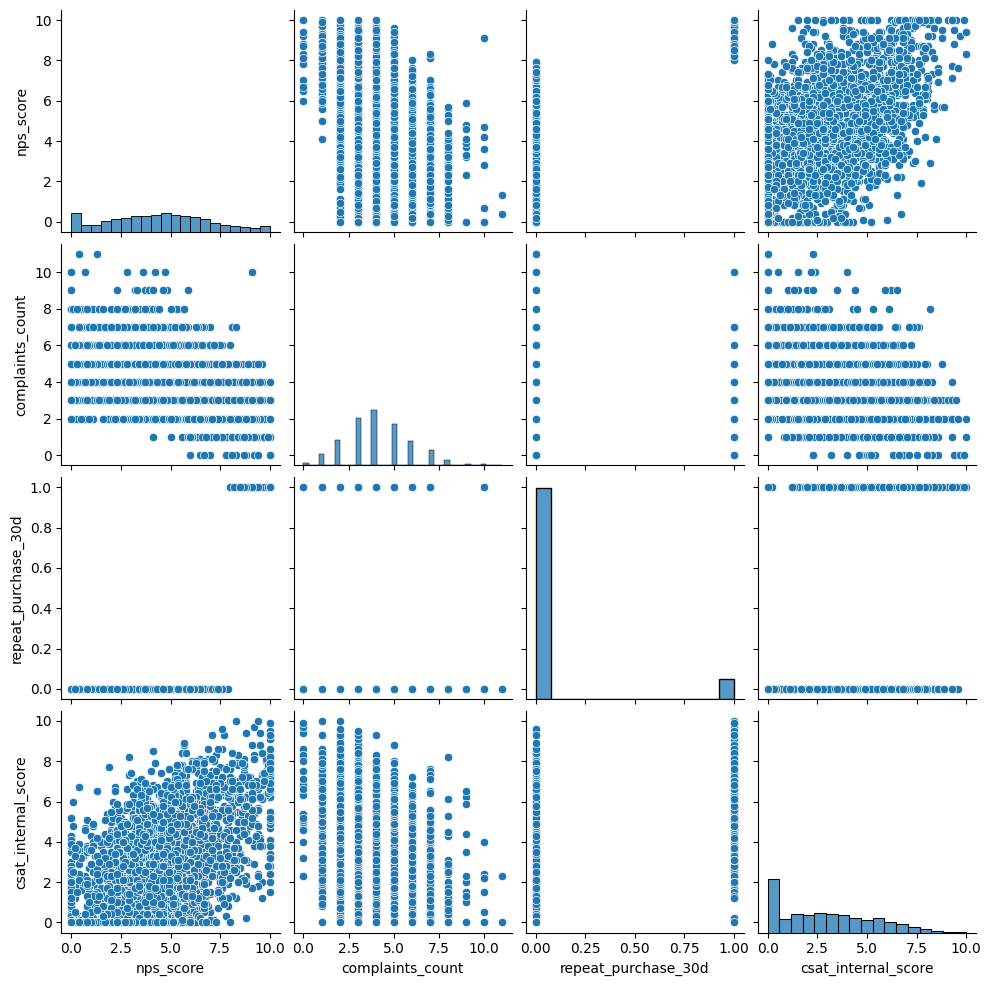

In [104]:
sns.pairplot(data[['nps_score', 'complaints_count', 'repeat_purchase_30d', 'csat_internal_score']])

## Median from Customer Region

In [131]:
print("Median TOTAL from nps and customer region:")
print("\n")

total = data.groupby('customer_region')['nps_score'].median()
display(total)

print("\n")
print("---------------------------------------------------------------------------------------")
print("Median PROMOTERS from nps and customer region:")
print("\n")

promoter = promoters.groupby('customer_region')['nps_score'].median()
display(promoter)

print("\n")
print("---------------------------------------------------------------------------------------")
print("Median NEUTRAL from nps and customer region:")
print("\n")
passive = neutral.groupby('customer_region')['nps_score'].median()
display(passive)


print("\n")
print("---------------------------------------------------------------------------------------")
print("Median DETRACTORS from nps and customer region:")
print("\n")
detractor = detractors.groupby('customer_region')['nps_score'].median()
display(detractor)



Median TOTAL from nps and customer region:




,nps_score
customer_region,
Centro-Oeste,4.2
Nordeste,4.5
Norte,4.5
Sudeste,4.3
Sul,4.5




---------------------------------------------------------------------------------------
Median PROMOTERS from nps and customer region:




,nps_score
customer_region,
Centro-Oeste,9.20
Nordeste,9.20
Norte,8.85
Sudeste,9.00
Sul,8.90




---------------------------------------------------------------------------------------
Median NEUTRAL from nps and customer region:




,nps_score
customer_region,
Centro-Oeste,6.85
Nordeste,6.75
Norte,6.80
Sudeste,6.90
Sul,6.80




---------------------------------------------------------------------------------------
Median DETRACTORS from nps and customer region:




,nps_score
customer_region,
Centro-Oeste,3.30
Nordeste,3.60
Norte,3.60
Sudeste,3.45
Sul,3.50
